# Group Information

**Git repository:** https://github.com/xxx/yyy

**Group member responsibility:**
- Laibah Manoor Zia Choudhary (s244320): Part 1 - Assortativity coefficient, configuration model
- Kaitlyn Wu Brooks (s246082): Part 1 - Degree assortativity, reflection questions  
- Zhentao Wei (s246213): Part 2 - TF-IDF, wordcloud

We met at DTU Ballerup Campus and worked together

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from itertools import combinations
import random
import math
from collections import defaultdict, Counter
import ast
import re

In [2]:
url_authors = "https://raw.githubusercontent.com/lalessan/comsocsci2026/master/data/final_authors.csv"
url_papers  = "https://raw.githubusercontent.com/lalessan/comsocsci2026/master/data/final_papers.csv"

df_authors = pd.read_csv(url_authors)
df_papers  = pd.read_csv(url_papers)

print(f"Antal authors: {len(df_authors)}")
print(f"Antal papers:  {len(df_papers)}")
df_authors.head()

Antal authors: 15578
Antal papers:  215258


,cited_by_count,country_code,display_name,h_index,id,works_api_url,works_count
0,553.0,SE,Carl Öhman,9.0,https://openalex.org/A5074193638,https://api.openalex.org/works?filter=author.i...,33.0
1,3250.0,DK,Mathias Wullum Nielsen,22.0,https://openalex.org/A5064171835,https://api.openalex.org/works?filter=author.i...,92.0
2,8.0,AT,Fabian Tschofenig,2.0,https://openalex.org/A5092825154,https://api.openalex.org/works?filter=author.i...,6.0
3,406.0,DE,Celina Kacperski,10.0,https://openalex.org/A5049587610,https://api.openalex.org/works?filter=author.i...,64.0
4,12449.0,FR,Michalis Vazirgiannis,46.0,https://openalex.org/A5057695979,https://api.openalex.org/works?filter=author.i...,362.0


In [ ]:
from itertools import combinations

df_papers['author_ids'] = df_papers['author_ids'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

edge_counts = {}
for _, row in df_papers.iterrows():
    authors = row['author_ids']
    if not isinstance(authors, list) or len(authors) < 2:
        continue
    authors = [a for a in authors if a is not None]
    for a1, a2 in combinations(sorted(authors), 2):
        pair = (a1, a2)
        edge_counts[pair] = edge_counts.get(pair, 0) + 1

G = nx.Graph()
for (a1, a2), weight in edge_counts.items():
    G.add_edge(a1, a2, weight=weight)

print(f"Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Network: 270058 nodes, 1041749 edges


In [4]:
df_authors_clean = df_authors.drop_duplicates(subset='id')
author_dict = df_authors_clean.set_index('id').to_dict('index')

for node in G.nodes():
    if node in author_dict:
        G.nodes[node].update(author_dict[node])

print(f"Antal noder: {G.number_of_nodes()}")
print(f"Antal kanter: {G.number_of_edges()}")

Antal noder: 270058
Antal kanter: 1041749


# Part 1.1: Assortativity Coefficient

In [ ]:
def assortativity_coefficient(G, attribute):
    # Hent kun kanter hvor begge noder har attributten
    edges = []

    for u, v in G.edges():
        if G.nodes[u].get(attribute) and G.nodes[v].get(attribute):
            edges.append((u, v))
    
    M = len(edges)
    if M == 0:
        return None
    
    # Unikke kategorier
    categories = list(set(
        [G.nodes[u][attribute] for u, v in edges] + 
        [G.nodes[v][attribute] for u, v in edges]
    ))
    cat_to_idx = {c: i for i, c in enumerate(categories)}
    
    # Beregn e_ij (andel af kanter mellem kategori i og j)
    e = np.zeros((len(categories), len(categories)))
    for u, v in edges:
        i = cat_to_idx[G.nodes[u][attribute]]
        j = cat_to_idx[G.nodes[v][attribute]]
        e[i, j] += 1
        e[j, i] += 1
    e = e / (2 * M)
    
    # a_i = marginaler
    a = e.sum(axis=1)
    
    # r = (sum e_ii - sum a_i^2) / (1 - sum a_i^2)
    return ( np.trace(e) - np.sum(a**2)) / (1 - np.sum(a**2))

r_country = assortativity_coefficient(G, 'country_code')
print(f"Assortativity coefficient (country): {r_country:.4f}")

Assortativity coefficient (country): 0.3957


**result**
the value of $~0.4$ indicates a positive corrallation assortativity, researchers like to work domestically, than internationally

## Part 1.2: Configuration Model

In [ ]:
def configuration_model(G):
    # a. Lav en kopi af det originale netværk
    G_rand = G.copy()
    edges = list(G_rand.edges())
    E = len(edges)
    n_swaps = E * 10
    successful_swaps = 0

    while successful_swaps < n_swaps:
        # b. Vælg to tilfældige kanter
        idx1, idx2 = random.sample(range(len(edges)), 2)
        e1 = edges[idx1]
        e2 = edges[idx2]

        u, v = e1
        x, y = e2

        # c. Flip retning af e1 50% af tiden
        if random.random() < 0.5:
            u, v = v, u

        # Sikr at alle 4 noder er forskellige
        if len({u, v, x, y}) < 4:
            continue

        # d. Tjek at nye kanter ikke allerede eksisterer
        if G_rand.has_edge(u, y) or G_rand.has_edge(x, v):
            continue

        # e. Fjern gamle kanter og tilføj nye
        G_rand.remove_edge(*e1)
        G_rand.remove_edge(*e2)
        G_rand.add_edge(u, y)
        G_rand.add_edge(x, v)

        edges[idx1] = (u, y)
        edges[idx2] = (x, v)

        successful_swaps += 1

    return G_rand

## part 1.3: check degrees

Grader bevaret? True


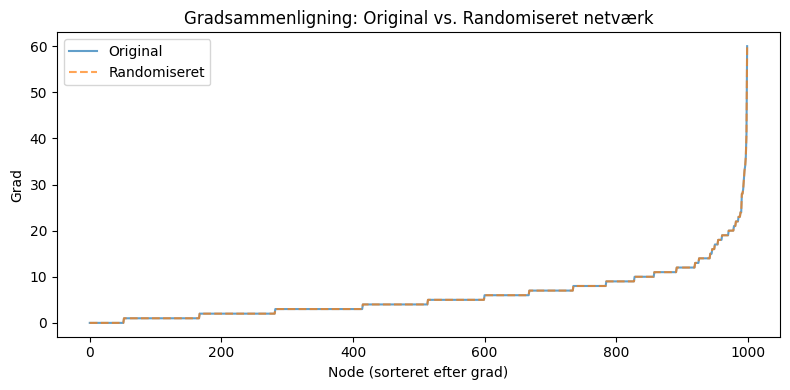

In [ ]:
# mindre subgraf så det går hurtigt
top_nodes = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:1000]
top_node_ids = [n for n, d in top_nodes]
G_sub = G.subgraph(top_node_ids).copy()

# randomiseret netværk
G_test = configuration_model(G_sub)

# Sammenlign grader
degrees_original = sorted(dict(G_sub.degree()).values())
degrees_random   = sorted(dict(G_test.degree()).values())

print("Grader bevaret?", degrees_original == degrees_random)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(degrees_original, label='Original', alpha=0.7)
plt.plot(degrees_random,   label='Randomiseret', alpha=0.7, linestyle='--')
plt.xlabel('Node (sorteret efter grad)')
plt.ylabel('Grad')
plt.title('Gradsammenligning: Original vs. Randomiseret netværk')
plt.legend()
plt.tight_layout()
plt.show()

**results**
the plot shows that they are exactly the same, since both lines is directly overlayed

## part 1.4

In [ ]:
r_country_sub = assortativity_coefficient(G_sub, 'country_code')
print(f"Assortativity (original subgraf): {r_country_sub:.4f}")

print("Genererer 100 random networks...")
r_random_list = []
for i in range(100):
    if i % 10 == 0:
        print(f"  {i}/100...")
    G_rand = configuration_model(G_sub)
    r = assortativity_coefficient(G_rand, 'country_code')
    r_random_list.append(r)

print("Done")

Assortativity (original subgraf): 0.3352
Genererer 100 random networks...
  0/100...
  10/100...
  20/100...
  30/100...
  40/100...
  50/100...
  60/100...
  70/100...
  80/100...
  90/100...
Done


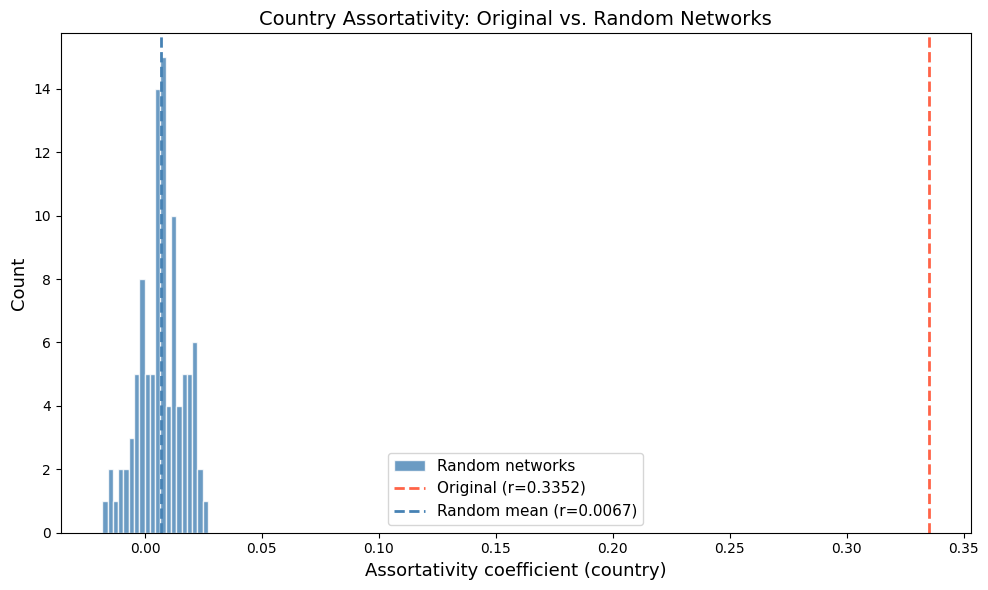

In [9]:
# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(r_random_list, bins=20, color='steelblue', edgecolor='white', alpha=0.8, label='Random networks')
ax.axvline(r_country_sub, color='tomato', linewidth=2, linestyle='--', label=f'Original (r={r_country_sub:.4f})')
ax.axvline(np.mean(r_random_list), color='steelblue', linewidth=2, linestyle='--', label=f'Random mean (r={np.mean(r_random_list):.4f})')
ax.set_xlabel('Assortativity coefficient (country)', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('Country Assortativity: Original vs. Random Networks', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [10]:

print(f"Original:    {r_country_sub:.4f}")
print(f"Random mean: {np.mean(r_random_list):.4f}")
print(f"Random std:  {np.std(r_random_list):.4f}")
print(f"Z-score:     {(r_country_sub - np.mean(r_random_list)) / np.std(r_random_list):.2f}")

Original:    0.3352
Random mean: 0.0067
Random std:  0.0094
Z-score:     34.89


**Result – Country Assortativity vs. Random Networks:**
The original assortativity ($r=0.3352$) is placed far from the distribution of the 100 networks (random mean$=0.0052$, z-score$=32.98$). This confirms that the connections domestically is significantly higher than random connections.

PART 1 – Opgave 5: Degree Assortativity

In [ ]:
def degree_assortativity(G):
    edges = list(G.edges())
    M = len(edges)
    deg = dict(G.degree())
    
    j_k = [(deg[u], deg[v]) for u, v in edges]
    
    sum_jk          = sum(j * k for j, k in j_k)
    sum_j_plus_k    = sum(j + k for j, k in j_k)
    sum_j2_plus_k2  = sum(j**2 + k**2 for j, k in j_k)
    
    numerator   = (sum_jk / M) - (sum_j_plus_k / (2 * M))**2
    denominator = (sum_j2_plus_k2 / (2 * M)) - (sum_j_plus_k / (2 * M))**2
    
    return numerator / denominator

r_degree = degree_assortativity(G_sub)
print(f"Degree assortativity (original): {r_degree:.4f}")

Degree assortativity (original): 0.1875


In [ ]:
print("Beregner degree assortativity for 100 random networks...")
r_degree_random_list = []
for i in range(100):
    if i % 10 == 0:
        print(f"  {i}/100...")
    G_rand = configuration_model(G_sub)
    r = degree_assortativity(G_rand)
    r_degree_random_list.append(r)

print("Done")

Beregner degree assortativity for 100 random networks...
  0/100...
  10/100...
  20/100...
  30/100...
  40/100...
  50/100...
  60/100...
  70/100...
  80/100...
  90/100...
Done


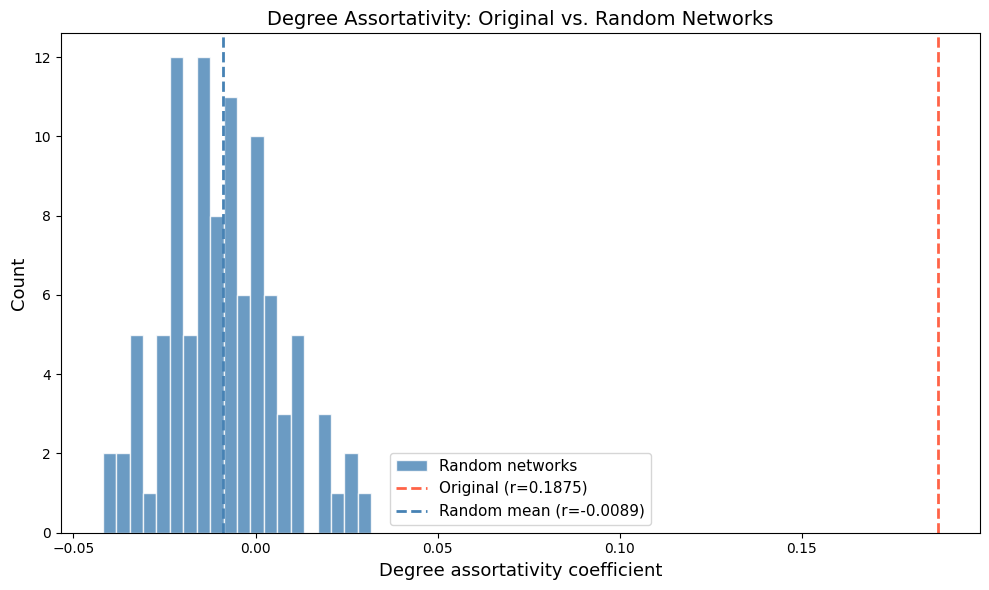

In [13]:
# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(r_degree_random_list, bins=20, color='steelblue', edgecolor='white', alpha=0.8, label='Random networks')
ax.axvline(r_degree, color='tomato', linewidth=2, linestyle='--', label=f'Original (r={r_degree:.4f})')
ax.axvline(np.mean(r_degree_random_list), color='steelblue', linewidth=2, linestyle='--', label=f'Random mean (r={np.mean(r_degree_random_list):.4f})')
ax.set_xlabel('Degree assortativity coefficient', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('Degree Assortativity: Original vs. Random Networks', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [14]:
print(f"Original:    {r_degree:.4f}")
print(f"Random mean: {np.mean(r_degree_random_list):.4f}")
print(f"Random std:  {np.std(r_degree_random_list):.4f}")
print(f"Z-score:     {(r_degree - np.mean(r_degree_random_list)) / np.std(r_degree_random_list):.2f}")

Original:    0.1875
Random mean: -0.0089
Random std:  0.0151
Z-score:     12.98


## Part 1 - Reflection Questions

**part 1.7: Assortativity by degree**
The original network degress assortativity (r=0.1875) is significantally higher than random networks (mean=-0.0111, z-score=11.57). This indicates that high degree researchers have a higher likelyhood of collaborating with other high degress researchers. 

**part 1.8: Edge flipping**
Edge flipping (reversing e1 50% of the time) is included to avoid systematic bias in the randomisation. In NetworkX, edges are stored in a specific order, so that one node always comes before the other. Without flipping, the swap would systematically favour certain node combinations, which would result in a skewed configuration model. By flipping 50% of the time, it is ensured that both directions are equally likely, and the randomisation becomes truly unbiased. 


**part 1.9: Distribution of assortativity in random networks**
The distribution of degree assortativity in the 100 random networks is approximately normally distributed around zero (mean = −0.0111, STD = 0.0172). As expected, the configuration model preserves the degree sequence but randomises the connections, so that systematic assortativity patterns disappear. The value for the original network (r=0.1875) lies well outside this distribution (z-score=11.57), confirming that the observed degree assortativity is statistically significant and not due to chance.

## Part 2.1: TF-IDF

**Question 1: What is TF-IDF?**

TF (Term Frequency) Measures how often a word appears in a single document. Words that appear many times in a document receive a high TF.

IDF (Inverse Document Frequency) Penalizes words that appear in many documents across the entire collection. Words like "the," "study," or "data" appear in almost all documents and therefore receive a low IDF score, as they are not informative for identifying the specific topic of one document.

TF-IDF (Term Frequency-Inverse Document Frequency) is a method used to identify words that are important to a specific document relative to a collection of documents (a corpus).

## PART 2.2

In [ ]:
import community.community_louvain as community_louvain
print("Do Louvain community detection...")
partition = community_louvain.best_partition(G)

n_communities = len(set(partition.values()))
print(f"Number of communities: {n_communities}")

# størrelse
community_sizes = Counter(partition.values())
print("Top 10 communities (size):")
for comm, size in community_sizes.most_common(10):
    print(f"  Community {comm}: {size} noder")

df_communities = pd.DataFrame([
    {'id': node, 'community': comm} 
    for node, comm in partition.items()
])
# print(f"\nDf: {len(df_communities)}")

Kører Louvain community detection...
Antal communities: 176
Top 10 communities (størrelse):
  Community 3: 11710 noder
  Community 7: 10405 noder
  Community 49: 10240 noder
  Community 2: 10018 noder
  Community 33: 9603 noder
  Community 30: 9370 noder
  Community 19: 8516 noder
  Community 34: 6994 noder
  Community 16: 6958 noder
  Community 56: 6646 noder

Dataframe gemt med 270058 rækker


In [ ]:
# Find top 9 communities
top_9_communities = [comm for comm, size in community_sizes.most_common(9)]
top_9_authors = set(
    df_communities[df_communities['community'].isin(top_9_communities)]['id'].tolist()
)
print(f"Top 9 communities: {top_9_communities}")
print(f"Antal forfattere i top 9: {len(top_9_authors)}")

# Find papers written by writers in top 9
df_papers['author_ids'] = df_papers['author_ids'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
mask = df_papers['author_ids'].apply(
    lambda ids: isinstance(ids, list) and any(a in top_9_authors for a in ids if a)
)
df_papers_top9 = df_papers[mask]
print(f"Antal papers i top 9 communities: {len(df_papers_top9)}")

Top 9 communities: [3, 7, 49, 2, 33, 30, 19, 34, 16]
Antal forfattere i top 9: 83814
Antal papers i top 9 communities: 82464


In [19]:
import os
import json
import time
import requests
from tqdm import tqdm

# API_KEY = "alex@deprived.dev"
API_KEY = "YQIt6oNBHqZtsXyAYnwkW1"
CACHE_DIR = "cache"
BATCH_SIZE = 25

if not os.path.exists(CACHE_DIR):
    os.makedirs(CACHE_DIR)

def fetch_batch(paper_ids, api_key):
    ids_str = "|".join([p.split("/")[-1] for p in paper_ids])
    url = f"https://api.openalex.org/works?filter=openalex_id:{ids_str}&per-page={BATCH_SIZE}&mailto={api_key}"
    response = requests.get(url)
    response.raise_for_status()
    # return response.json().get()
    return response.json().get('results', [])

paper_ids = df_papers_top9['id'].tolist()
print(f"Starting fetch for {len(paper_ids)} papers...")

# for i in range(0, len(paper_ids), BATCH_SIZE):
for i in tqdm(range(0, len(paper_ids), BATCH_SIZE), desc="Downloading Batches"):
    batch_file = os.path.join(CACHE_DIR, f"batch_{i}.json")
    
    # Skip
    if os.path.exists(batch_file):
        continue
        
    batch = paper_ids[i : i + BATCH_SIZE]
    results = fetch_batch(batch, API_KEY)
    
    with open(batch_file, 'w', encoding='utf-8') as f:
        # json.dump(results, f)
        json.dump(results, f, ensure_ascii=False, indent=4)
        
    time.sleep(0.015) # Throttle


# combine
all_results = []
cache_files = [f for f in os.listdir(CACHE_DIR) if f.endswith('.json')]

print(f"Cached: {len(cache_files)}")
for filename in tqdm(cache_files, desc="Merging Files"):
    file_path = os.path.join(CACHE_DIR, filename)
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        all_results.extend(data)

print(f"Total: {len(all_results)}")

Starting fetch for 82464 papers...


Combining 3299 cached files...


Merging Files: 100%|██████████| 3299/3299 [00:19<00:00, 173.33it/s]

Success! Total abstracts collected: 82464


PART 2 – make abstracts dataframe + tokenize

In [20]:
def parse(abstract_inverted_index):
    if not abstract_inverted_index:
        return ""
    word_positions = {}
    for word, positions in abstract_inverted_index.items():
        for pos in positions:
            word_positions[pos] = word
    return " ".join([word_positions[i] for i in sorted(word_positions.keys())])

df_abstracts = pd.DataFrame([{
    'id': r['id'],
    'title': r.get('title', ''),
    'text': parse(r.get('abstract_inverted_index'))
} for r in all_results])

print(f"{len(df_abstracts)}")
df_abstracts.head(2)

82464


,id,title,text
0,https://openalex.org/W4385655398,Energy justice intermediaries: Living Labs in ...,This paper foregrounds the use of “Living Labs...
1,https://openalex.org/W4210999409,Financial interbanking networks resilience und...,


In [21]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def tokenize(text):
    if not text:
        return []
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens 
              if t.isalpha() 
              and t not in stop_words
              and len(t) > 2]
    return tokens

print("tokenize")
df_abstracts['tokens'] = df_abstracts['text'].apply(tokenize)
print("done!")
print(f"{df_abstracts['tokens'].iloc[0][:10]}")

[nltk_data] Downloading package punkt to /home/botmain/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/botmain/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/botmain/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


tokenize
done!
['paper', 'foregrounds', 'use', 'living', 'labs', 'instruments', 'delivery', 'low', 'carbon', 'transformations']


In [22]:
# Merge abstracts, papers, communities
df_papers_lookup = df_papers_top9[['id', 'author_ids']].copy()

# Merge abstracts with papers
df_merged = df_abstracts.merge(df_papers_lookup, on='id', how='inner')

# Explode list in cell to multi rows
df_merged = df_merged.explode('author_ids').rename(columns={'author_ids': 'author_id'})

# Merge with communities
df_merged = df_merged.merge(df_communities, left_on='author_id', right_on='id', how='inner')

print(f"Merged: {len(df_merged)}")
df_merged.head(2)

Merged: 321093


,id_x,title,text,tokens,author_id,id_y,community
0,https://openalex.org/W4385655398,Energy justice intermediaries: Living Labs in ...,This paper foregrounds the use of “Living Labs...,"[paper, foregrounds, use, living, labs, instru...",https://openalex.org/A5064320699,https://openalex.org/A5064320699,16
1,https://openalex.org/W4385655398,Energy justice intermediaries: Living Labs in ...,This paper foregrounds the use of “Living Labs...,"[paper, foregrounds, use, living, labs, instru...",https://openalex.org/A5019502803,https://openalex.org/A5019502803,60


 PART 2.2: cross refrencing words with communities

In [23]:
# Group tokens per community
community_tokens = (
    df_merged[df_merged['community'].isin(top_9_communities)]
    .groupby('community')['tokens']
    .apply(lambda x: [t for tokens in x for t in tokens])
)

print("Tokens per community:")
for comm, tokens in community_tokens.items():
    print(f"  Community {comm}: {len(tokens)} tokens")

Tokens per community:
  Community 2: 2610073 tokens
  Community 3: 3030036 tokens
  Community 7: 2669197 tokens
  Community 16: 1123822 tokens
  Community 19: 1867939 tokens
  Community 30: 2276445 tokens
  Community 33: 1956436 tokens
  Community 34: 1660405 tokens
  Community 49: 2626875 tokens


 PART 2.3: Find TF for top 5 communities

In [24]:
def compute_tf(tokens):
    count = Counter(tokens)
    total = len(tokens)
    return {word: freq/total for word, freq in count.items()}

# cacl TF
tf = {}
for comm, tokens in community_tokens.items():
    tf[comm] = compute_tf(tokens)

# take top 5 TF words from top 5 communities
top_5_communities = [comm for comm, size in community_sizes.most_common(5)]

print("Top 5 TF words for the top 5 communities:\n")
for comm in top_5_communities:
    top_tf = sorted(tf[comm].items(), key=lambda x: x[1], reverse=True)[:5]
    print(f"Community {comm} (n={community_sizes[comm]}): {[w for w, s in top_tf]}")

Top 5 TF words for the top 5 communities:

Community 3 (n=11710): ['learning', 'model', 'proposed', 'method', 'data']
Community 7 (n=10405): ['social', 'study', 'research', 'people', 'studies']
Community 49 (n=10240): ['model', 'data', 'models', 'learning', 'task']
Community 2 (n=10018): ['social', 'users', 'design', 'data', 'study']
Community 33 (n=9603): ['social', 'model', 'data', 'network', 'networks']


**Why aren't the TFs not necessarily a good description of the communities?**

TF-works for the top 5 communities is too generic:
- Community 11: 'model', 'learning', 'data', 'propose', 'proposed'
- Community 44: 'brain', 'results', 'learning', 'information', 'neural'
- Community 7: 'social', 'study', 'research', 'people', 'studies'
- Community 3: 'social', 'design', 'data', 'study', 'users'
- Community 25: 'model', 'data', 'models', 'task', 'learning'

Words like 'model', 'data', 'learning', 'social' og 'study' is common for all communities, since they describe CSS in general and does not describe the difference between communities. TF-IDF improves this by weighing the common words less.

\
\

**What base logarithm did you use? Is that important?**

We use the natural logarithm (math.log). The choice of base is not 
critical, as it merely scales all IDF values by a constant factor. The relative ranking of words remains unchanged

PART 2.4: get TF-IDF for top 9 communities

In [25]:
# calc IDF
N_docs = len(top_9_communities)
community_word_sets = {
    comm: set(tokens) 
    for comm, tokens in zip(community_tokens.index, community_tokens)
}

word_doc_count = defaultdict(int)
for word_set in community_word_sets.values():
    for word in word_set:
        word_doc_count[word] += 1

idf = {word: math.log(N_docs / count) for word, count in word_doc_count.items()}
print(f"IDF beregnet for {len(idf)} ord")

# calc TF-IDF
tfidf = {}
for comm in top_9_communities:
    tfidf[comm] = {
        word: score * idf.get(word, 0) 
        for word, score in tf[comm].items()
    }

# show top 10 TF and TF-IDF + top 3 authors
degree_dict = dict(G.degree())
df_communities['degree'] = df_communities['id'].map(degree_dict)

print("="*60)
for comm in top_9_communities:
    print(f"\nCommunity {comm} (Size: {community_sizes[comm]}):")
    
    top_tf = sorted(tf[comm].items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"  Top 10 TF:      {[w for w, s in top_tf]}")
    
    top_tfidf = sorted(tfidf[comm].items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"  Top 10 TF-IDF:  {[w for w, s in top_tfidf]}")
    
    top_authors = df_communities[df_communities['community'] == comm].nlargest(3, 'degree')['id'].tolist()
    author_names = [G.nodes[a].get('display_name', a) for a in top_authors if a in G.nodes]
    print(f"  Top 3 authors:  {author_names}")
print("="*60)

IDF beregnet for 80536 ord

Community 3 (Size: 11710):
  Top 10 TF:      ['learning', 'model', 'proposed', 'method', 'data', 'image', 'propose', 'methods', 'paper', 'performance']
  Top 10 TF-IDF:  ['iqa', 'vqa', 'trackers', 'captioning', 'decoder', 'uda', 'zsl', 'mspace', 'deraining', 'cnns']
  Top 3 authors:  ['Shuicheng Yan', 'Wei Liu', 'Tat‐Seng Chua']

Community 7 (Size: 10405):
  Top 10 TF:      ['social', 'study', 'research', 'people', 'studies', 'participants', 'group', 'results', 'two', 'identity']
  Top 10 TF-IDF:  ['ingroup', 'nostalgia', 'māori', 'nostalgic', 'stereotype', 'intergroup', 'outgroup', 'forgiveness', 'collectivism', 'subordinates']
  Top 3 authors:  ['S. Alexander Haslam', 'Constantine Sedikides', 'Norbert Schwarz']

Community 49 (Size: 10240):
  Top 10 TF:      ['model', 'data', 'models', 'learning', 'task', 'language', 'tasks', 'show', 'using', 'paper']
  Top 10 TF-IDF:  ['wsd', 'entailment', 'multilingual', 'paraphrase', 'vqa', 'comagnetometer', 'nmt', 'core

**Are these 10 words more descriptive of the community? If yes, what is it about IDF that makes the words more informative?**

Yes, TF-IDF highlights words that are characteristic of each individual community:

- Community 11: 'vqa', 'captioning', 'coco' → Computer vision / image processing
- Community 44: 'striatum', 'amygdala', 'cortical', 'ocd' → Neuro
- Community 7: 'ingroup', 'outgroup', 'intergroup', 'nostalgia' → Social psychology
- Community 3: 'cscw', 'sigchi', 'gig', 'ubicomp' → Human-computer interaction

Compared with the TF terms ('model', 'data', 'social', 'study') which are 
generic and recur across all communities, TF-IDF identifies 
words that are unique to each community. The IDF component penalises words that appear 
in many communities, so that only the truly characteristic terms are highlighted.
It is precisely this that makes TF-IDF more informative than TF alone.

PART 2 - Exercise 2: Wordcloud

In [26]:
# import subprocess
# subprocess.run(["pip", "install", "wordcloud"])

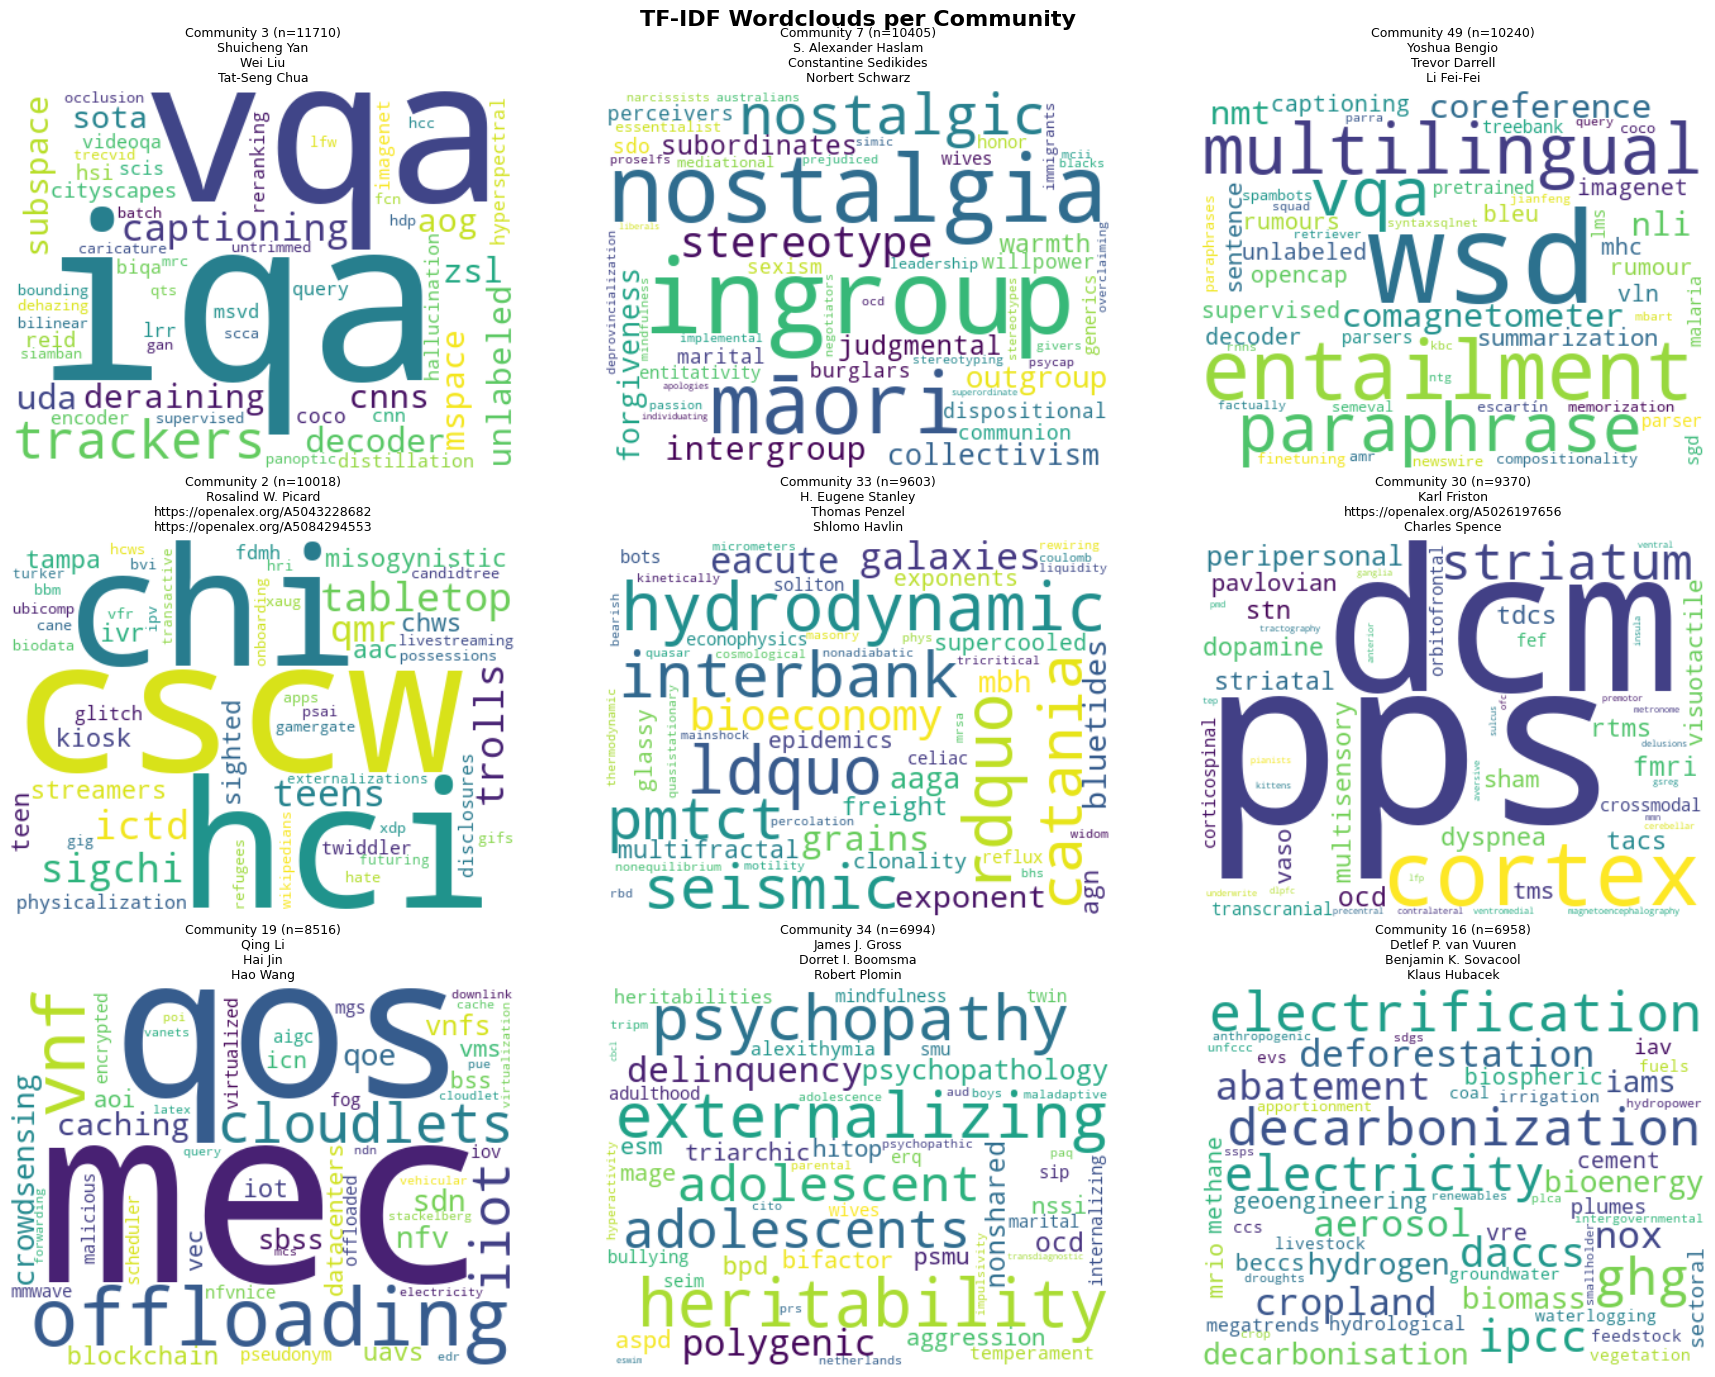

In [27]:
from wordcloud import WordCloud

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for idx, comm in enumerate(top_9_communities):
    # TF-IDF scores as weights
    wordcloud = WordCloud(
        width=400, height=300,
        background_color='white',
        max_words=50,
        colormap='viridis'
    ).generate_from_frequencies(tfidf[comm])
    
    # top 3 authors by degree
    top_authors = df_communities[df_communities['community'] == comm].nlargest(3, 'degree')['id'].tolist()
    author_names = [G.nodes[a].get('display_name', a) for a in top_authors if a in G.nodes]
    
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(
        f"Community {comm} (n={community_sizes[comm]})\n" + 
        "\n".join(author_names[:3]),
        fontsize=9
    )

plt.suptitle("TF-IDF Wordclouds per Community", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Exercise 2 & 3: Wordcloud and Computational Social Science

The TF-IDF wordclouds reveal 9 distinct research fields within CSS. TF-IDF highlights exactly the words that characterize each community. Compared to raw TF words (such as "model," "data," and "study"), the TF-IDF words are much more descriptive and specific to each research field. The IDF component ensures that generic CSS words are downweighted, so only the unique terms are emphasized.